In [11]:
from torch.utils.data import Dataset
from PIL import Image
import json
import os

class CocoDetrDataset(Dataset):
    def __init__(self, img_dir, ann_file, processor):
        with open(ann_file) as f:
            coco = json.load(f)

        self.images = coco["images"]
        self.annotations = coco["annotations"]
        self.processor = processor
        self.img_dir = img_dir

        # group annotations by image
        self.ann_map = {}
        for ann in self.annotations:
            self.ann_map.setdefault(ann["image_id"], []).append(ann)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.img_dir, img_info["file_name"])

        image = Image.open(img_path).convert("RGB")
        anns = self.ann_map.get(img_info["id"], [])

        # ✅ FIXED ANNOTATIONS
        fixed_anns = []
        for ann in anns:
            ann = ann.copy()

            # bbox stays in COCO format [x, y, w, h]
            x, y, w, h = ann["bbox"]
            ann["bbox"] = [float(x), float(y), float(w), float(h)]

            # ✅ CRITICAL: keep class = 0
            ann["category_id"] = 0

            fixed_anns.append(ann)

        encoding = self.processor(
            images=image,
            annotations={
                "image_id": int(img_info["id"]),
                "annotations": fixed_anns
            },
            return_tensors="pt"
        )

        return {
            "pixel_values": encoding["pixel_values"].squeeze(0),
            "pixel_mask": encoding["pixel_mask"].squeeze(0),
            "labels": encoding["labels"][0]
        }


    def __len__(self):
        return len(self.images)

In [12]:
from transformers import DetrForObjectDetection, DetrImageProcessor
import torch 

model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=1,
    ignore_mismatched_sizes=True
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                            

In [13]:
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = processor.pad(pixel_values, return_tensors="pt")

    labels = [item["labels"] for item in batch]

    return {
        "pixel_values": encoding["pixel_values"],
        "pixel_mask": encoding["pixel_mask"],
        "labels": labels,
    }

In [14]:
from torch.utils.data import DataLoader

train_dataset = CocoDetrDataset(
    "/home/astik/Downloads/pothole_detection/split/train/images",
    "/home/astik/Downloads/pothole_detection/split/train/annotations.json",
    processor
)

val_dataset = CocoDetrDataset(
    "/home/astik/Downloads/pothole_detection/split/val/images",
    "/home/astik/Downloads/pothole_detection/split/val/annotations.json",
    processor
)

test_dataset = CocoDetrDataset(
    "/home/astik/Downloads/pothole_detection/split/test/images",
    "/home/astik/Downloads/pothole_detection/split/test/annotations.json",
    processor
)

train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=3, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=3, shuffle=False, collate_fn=collate_fn)

sample = train_dataset[0]

print(sample["labels"])

{'size': tensor([800, 800]), 'image_id': tensor([0]), 'class_labels': tensor([0, 0, 0, 0, 0]), 'boxes': tensor([[0.5278, 0.4083, 0.3583, 0.2861],
        [0.3792, 0.3611, 0.1667, 0.1139],
        [0.2618, 0.5521, 0.0903, 0.0597],
        [0.0708, 0.8500, 0.1417, 0.1389],
        [0.9778, 0.6326, 0.0444, 0.1236]]), 'area': tensor([65614.8125, 12148.1475,  3450.6172, 12592.5928,  3516.0493]), 'iscrowd': tensor([0, 0, 0, 0, 0]), 'orig_size': tensor([720, 720])}


 40%|████      | 158/394 [01:31<02:25,  1.62it/s]/home/astik/anaconda3/envs/drones/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:864: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 394/394 [03:45<00:00,  1.74it/s]



Epoch 0 Train Loss: 2.1966
Epoch 0 Val Loss:   1.7667
Learning Rate: 0.00001000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best model!


100%|██████████| 394/394 [03:41<00:00,  1.78it/s]


...


Epoch 27 Train Loss: 0.8050
Epoch 27 Val Loss:   1.1051
Learning Rate: 0.00000500


100%|██████████| 394/394 [03:42<00:00,  1.77it/s]



Epoch 28 Train Loss: 0.7831
Epoch 28 Val Loss:   1.1101
Learning Rate: 0.00000500


100%|██████████| 394/394 [03:38<00:00,  1.81it/s]



Epoch 29 Train Loss: 0.7583
Epoch 29 Val Loss:   1.1136
Learning Rate: 0.00000250


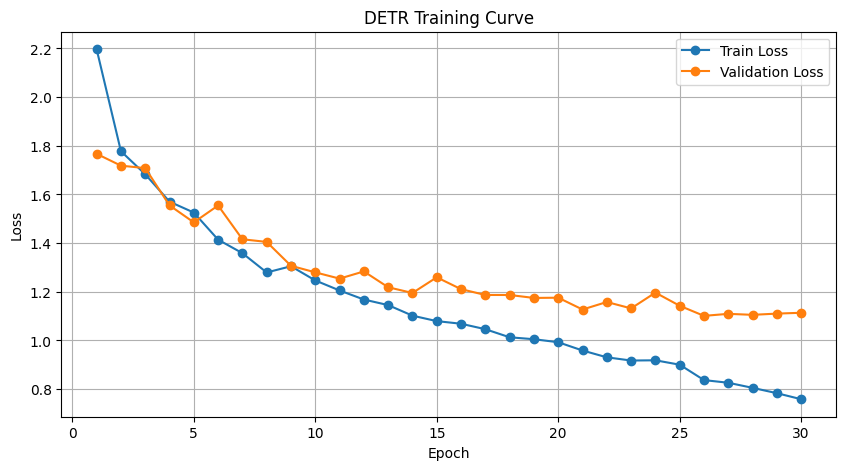

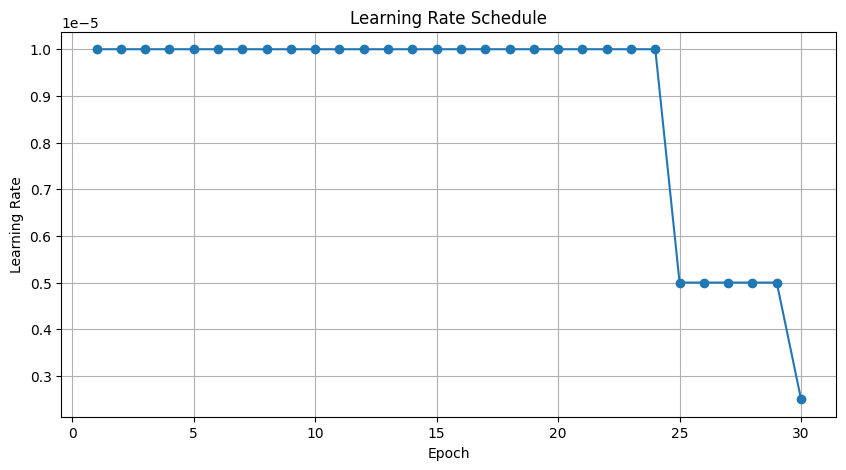

In [15]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# =====================================================
# Optimizer
# =====================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

# =====================================================
# LR Scheduler
# Reduces LR when val loss plateaus
# =====================================================
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,      # halve LR
    patience=3,      # wait 3 epochs
    min_lr=1e-7
)

best_val_loss = float("inf")
save_path = "best_model"

train_losses = []
val_losses = []
learning_rates = []

num_epochs = 30

# =====================================================
# TRAINING LOOP
# =====================================================
for epoch in range(num_epochs):

    # ---------------- TRAIN ----------------
    model.train()
    train_loss = 0

    for batch in tqdm(train_loader):

        batch = {
            k: v.to(device) if k != "labels"
            else [{kk: vv.to(device) for kk, vv in t.items()} for t in v]
            for k, v in batch.items()
        }

        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()

        loss.backward()

        # ==========================================
        # Gradient clipping (VERY IMPORTANT)
        # ==========================================
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=0.1
        )

        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    print(f"\nEpoch {epoch} Train Loss: {avg_train_loss:.4f}")

    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:

            batch = {
                k: v.to(device) if k != "labels"
                else [{kk: vv.to(device) for kk, vv in t.items()} for t in v]
                for k, v in batch.items()
            }

            outputs = model(**batch)
            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch} Val Loss:   {avg_val_loss:.4f}")

    # =====================================================
    # Scheduler step
    # IMPORTANT: after validation
    # =====================================================
    scheduler.step(avg_val_loss)

    # current LR
    current_lr = optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)

    print(f"Learning Rate: {current_lr:.8f}")

    # ---------------- SAVE BEST ----------------
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        model.save_pretrained(save_path)
        processor.save_pretrained(save_path)

        print("Saved best model!")

# =====================================================
# PLOT LOSSES
# =====================================================
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    train_losses,
    marker='o',
    label="Train Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker='o',
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DETR Training Curve")

plt.legend()
plt.grid(True)

plt.show()

# =====================================================
# PLOT LEARNING RATE
# =====================================================
plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    learning_rates,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")

plt.grid(True)

plt.show()

In [16]:
from transformers import DetrConfig, DetrForObjectDetection

# Load config as dict
config = DetrConfig.from_pretrained("/home/astik/pothole-detection/best_model")
cfg_dict = config.to_dict()

# 🔥 FIX backbone_config PROPERLY
bc = cfg_dict.get("backbone_config", {})

if "out_features" in bc:
    feature_map = {"stem": 0, "layer1": 1, "layer2": 2, "layer3": 3, "layer4": 4}

    bc["out_indices"] = [feature_map[f] for f in bc["out_features"]]
    bc.pop("out_features")   # ✅ works here (dict)

cfg_dict["backbone_config"] = bc

# Recreate config cleanly
fixed_config = DetrConfig.from_dict(cfg_dict)

# Load model
model = DetrForObjectDetection.from_pretrained(
    "/home/astik/pothole-detection/best_model",
    config=fixed_config,
    ignore_mismatched_sizes=True
).to(device)

model.eval()

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvEncoder(
      (model): FeatureListNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): DetrFrozenBatchNorm2d()
        (act1): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): DetrFrozenBatchNorm2d()
            (act1): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): DetrFrozenBatchNorm2d()
            (drop_block): Identity()
            (act2): ReLU(inplace=True)
            (aa): Identity()
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): DetrFrozenBatchNorm2d()
            (act3): ReLU(inplace

In [17]:
import torch

def box_iou(box1, box2):
    # box format: [x1, y1, x2, y2]
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    return inter / union if union > 0 else 0

In [18]:
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
import numpy as np

100%|██████████| 57/57 [00:17<00:00,  3.19it/s]



===== FINAL METRICS =====
Precision: 0.4755
Recall:    0.7595
mIoU:      0.7470
TP: 379, FP: 418, FN: 120


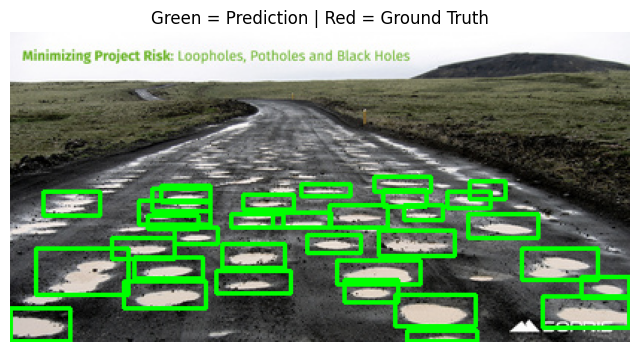

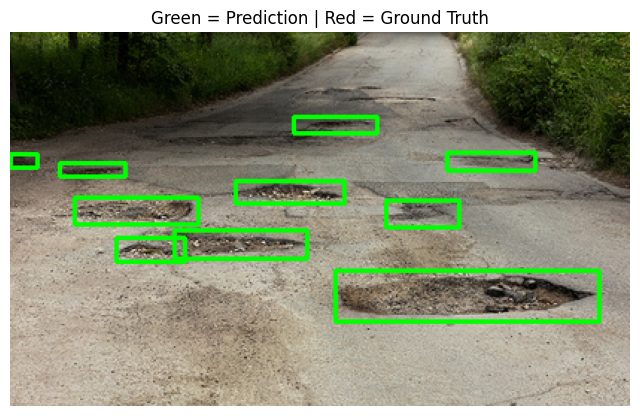

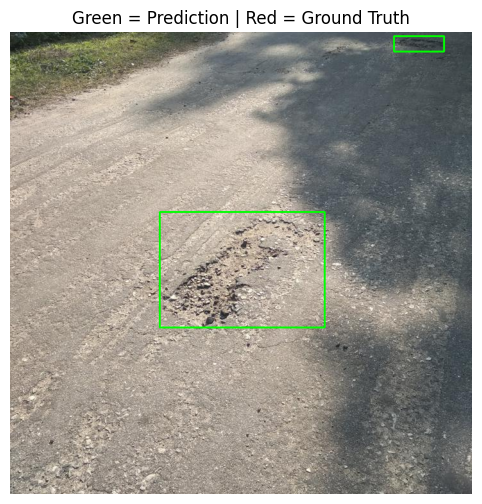

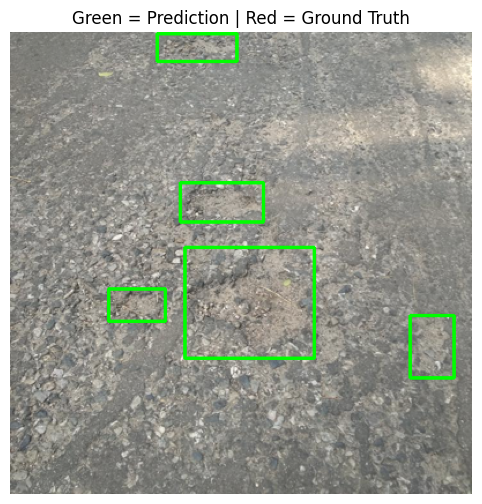

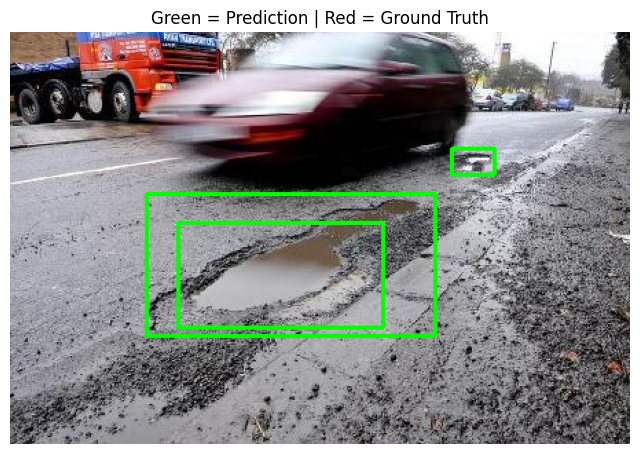

In [19]:
model.eval()

all_ious = []
TP, FP, FN = 0, 0, 0

with torch.no_grad():
    for batch in tqdm(test_loader):

        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)

        # 🔥 IMPORTANT: no labels in forward
        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask
        )

        target_sizes = torch.stack([
            t["orig_size"] for t in batch["labels"]
        ]).to(device)

        detections = processor.post_process_object_detection(
            outputs,
            target_sizes=target_sizes,
            threshold=0.5
        )

        for i, det in enumerate(detections):

            # ---------- GT ----------
            gt_boxes = batch["labels"][i]["boxes"]
            h, w = batch["labels"][i]["orig_size"]

            gt_xyxy = []
            for b in gt_boxes:
                cx, cy, bw, bh = b
                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                x2 = (cx + bw/2) * w
                y2 = (cy + bh/2) * h
                gt_xyxy.append([x1.item(), y1.item(), x2.item(), y2.item()])

            # ---------- PRED ----------
            pred_boxes = det["boxes"].cpu().numpy()

            matched_gt = set()

            for pb in pred_boxes:
                best_iou = 0
                best_j = -1

                for j, gb in enumerate(gt_xyxy):
                    if j in matched_gt:
                        continue
                    iou = box_iou(pb, gb)
                    if iou > best_iou:
                        best_iou = iou
                        best_j = j

                if best_iou > 0.5:
                    TP += 1
                    matched_gt.add(best_j)
                    all_ious.append(best_iou)
                else:
                    FP += 1

            FN += len(gt_xyxy) - len(matched_gt)


# -------------------------------
# FINAL METRICS
# -------------------------------
precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)
miou = np.mean(all_ious) if len(all_ious) > 0 else 0

print("\n===== FINAL METRICS =====")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"mIoU:      {miou:.4f}")
print(f"TP: {TP}, FP: {FP}, FN: {FN}")


# # -------------------------------
# # CONFUSION MATRIX
# # -------------------------------
# cm = np.array([
#     [TP, FP],
#     [FN, 0]
# ])

# plt.figure()
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=["Pred Pothole", "Pred Background"],
#             yticklabels=["GT Pothole", "GT Background"])
# plt.title("Confusion Matrix")
# plt.show()


# -------------------------------
# VISUALIZATION FUNCTION
# -------------------------------
def visualize_predictions(model, dataset, processor, device, n=5):

    model.eval()

    for _ in range(n):
        idx = random.randint(0, len(dataset)-1)

        sample = dataset[idx]
        img_info = dataset.images[idx]

        img_path = os.path.join(dataset.img_dir, img_info["file_name"])
        img = cv2.imread(img_path)

        # ---------- PRED ----------
        with torch.no_grad():
            outputs = model(
                pixel_values=sample["pixel_values"].unsqueeze(0).to(device),
                pixel_mask=sample["pixel_mask"].unsqueeze(0).to(device)
            )

        detections = processor.post_process_object_detection(
            outputs,
            target_sizes=[sample["labels"]["orig_size"]],
            threshold=0.5
        )[0]

        # Draw predictions (GREEN)
        for box in detections["boxes"]:
            x1, y1, x2, y2 = map(int, box.cpu().numpy())
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

        # Draw GT (RED)
        # h, w = sample["labels"]["orig_size"]
        # for b in sample["labels"]["boxes"]:
        #     cx, cy, bw, bh = b
        #     x1 = int((cx - bw/2) * w)
        #     y1 = int((cy - bh/2) * h)
        #     x2 = int((cx + bw/2) * w)
        #     y2 = int((cy + bh/2) * h)
        #     cv2.rectangle(img, (x1, y1), (x2, y2), (0,0,255), 2)

        plt.figure(figsize=(8,6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Green = Prediction | Red = Ground Truth")
        plt.axis("off")
        plt.show()


# -------------------------------
# RUN VISUALIZATION
# -------------------------------
visualize_predictions(model, test_dataset, processor, device, n=5)

In [ ]:
print(test_dataset.__len__())
visualize_predictions(model, test_dataset, processor, device, n=170)

170
